In [1]:
from datetime import datetime, timedelta
import mysql.connector
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import shap as sp
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

c:\Users\assetplan\Desktop\Códigos\repositorio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sqlalchemy
from utils import load_sql_query, Engine, logger
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

# Force pymysql instead of mysqlconnector
load_dotenv()
username = os.getenv("DATABASE_USERNAME")
password = quote_plus(os.getenv("DATABASE_PASSWORD"))
host = os.getenv("DATABASE_HOST")
database = os.getenv("DATABASE_NAME")

engine = Engine()  # create normally
engine.engine = sqlalchemy.create_engine(  # then swap the internal engine
    f'mysql+pymysql://{username}:{password}@{host}/{database}',
    pool_recycle=300,
    pool_pre_ping=True,
)

query = load_sql_query("query.sql")
dataframe = pd.read_sql(query, engine.engine)
dataframe.head()

,property_id,unit_id,created,acepta_mascotas,m2_utiles,edificio,sector_provincia,nombre_tipologia,first_time_rented,first_time_rp,actual_activa,ha_sido_arrendada,owner_id,monto_depto,event_date,churn,reception_date,owner_total_units,days_to_event,precio_recomendado_ml
0,473269,2538_322_3,2024-01-02,1,31.22,Jardines de Mapocho,Santiago - Centro,1D1B,2024-03-28 00:00:00,2024-02-21,1,Si,5129,345000.0,2024-03-18,0,2024-02-20,3.0,76,345000.0
1,473275,2102_1005_3,2024-01-02,0,31.00,RVC Castillo Urizar,Santiago - Nororiente,1D1B,2024-03-11 00:00:00,2024-01-24,1,Si,9505,450000.0,2024-03-08,0,2024-01-19,5.0,66,430000.0
2,473278,2102_1203_3,2024-01-02,1,42.00,RVC Castillo Urizar,Santiago - Nororiente,2D1B,2024-02-08 00:00:00,2024-01-22,1,Si,9505,465000.0,2024-02-08,0,2024-01-19,5.0,37,500000.0
3,473287,2506_310_3,2024-01-02,1,32.00,Activa Dominica,Santiago - Norte,1D1B,2024-02-28 00:00:00,2024-01-05,1,Si,9507,370000.0,2024-02-23,0,2024-01-04,4.0,52,370000.0
4,473288,2506_403_3,2024-01-02,1,32.00,Activa Dominica,Santiago - Norte,1D1B,2024-01-31 00:00:00,2024-01-05,1,Si,9507,355000.0,2024-01-22,0,2024-01-04,4.0,20,370000.0


In [ ]:
dataframe_churn_1 = dataframe[dataframe['churn'] == 1].copy()

mean_val = dataframe_churn_1['days_to_event'].mean()
std_val = dataframe_churn_1['days_to_event'].std()
med_val = dataframe_churn_1['days_to_event'].median()

plt.figure(figsize=(10, 6))
ax = sns.histplot(data=dataframe_churn_1, 
                  x='days_to_event', 
                  kde=True, 
                  color='skyblue',
                  bins=dataframe_churn_1['days_to_event'].nunique()) # Cantidad de días únicos)

plt.title('Distribución de Churn por Días de Salida')
plt.ylabel('Unidades')
plt.xlabel('Distribución Días de Salida')
plt.xticks(rotation=45)

plt.axvline(mean_val + std_val, color='red', linestyle=':', label=f'Desv. Estándar (+1) ({mean_val + std_val:.2f})')
plt.axvline(mean_val - std_val, color='red', linestyle=':', label=f'Desv. Estándar (-1) ({mean_val - std_val:.2f})')
plt.axvline(mean_val, color='grey', linestyle=':', label=f'Mean ({mean_val:.2f})')

# Get the y height of the tallest bar to position the annotation
y_max = ax.get_ylim()[1]

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Probabilidad de churn por día de salida
total_unique_properties = dataframe_churn_1['property_id'].nunique()

churn_prob_by_day = (
    dataframe_churn_1
    .groupby('days_to_event', as_index=False)['property_id']
    .nunique()
    .rename(columns={'property_id': 'unique_properties'})
    .sort_values('days_to_event')
)

churn_prob_by_day['prob_churn'] = (
    churn_prob_by_day['unique_properties'] / total_unique_properties
)

# Add probability back to each row by days_to_event
dataframe_churn_1 = dataframe_churn_1.merge(
    churn_prob_by_day[['days_to_event', 'prob_churn']],
    on='days_to_event',
    how='left'
 )

print(f'Total unique properties: {total_unique_properties}')
dataframe_churn_1

In [ ]:
# Gráfico correcto: probabilidad de churn por día
plot_df = (
    dataframe_churn_1[['days_to_event', 'prob_churn']]
    .drop_duplicates()
    .sort_values('days_to_event')
)

mean_val = plot_df['prob_churn'].mean()
std_val = plot_df['prob_churn'].std()
med_val = plot_df['prob_churn'].median()

plt.figure(figsize=(11, 7))
ax = sns.lineplot(
    data=plot_df,
    x='days_to_event',
    y='prob_churn',
    marker='o',
    color='steelblue'
 )

plt.title('Probabilidad de Churn por Días de Salida')
plt.xlabel('Días hasta churn')
plt.ylabel('Probabilidad de churn')
plt.xticks(rotation=45)

# Formula shown on the graph
formula_txt = r"$Probabilidad~de~Churn_{d}=\frac{\mathrm{N~propiedades~que~churned_{d}}}{\mathrm{Total~de~propiedades}}$"
plt.figtext(0.5, 0.01, formula_txt, ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray'))

# Reference lines must be horizontal because probability is on Y-axis
plt.axhline(mean_val + std_val, color='red', linestyle=':', label=f'Desv. Estándar (+1) ({mean_val + std_val:.4f})')
plt.axhline(mean_val - std_val, color='red', linestyle=':', label=f'Desv. Estándar (-1) ({mean_val - std_val:.4f})')
plt.axhline(mean_val, color='grey', linestyle=':', label=f'Media ({mean_val:.4f})')
plt.axhline(med_val, color='green', linestyle='--', label=f'Mediana ({med_val:.4f})')

plt.legend()
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [ ]:
# Same histogram, one chart per tipologia
tipologias = sorted(dataframe_churn_1['nombre_tipologia'].dropna().unique())

for tipologia in tipologias:
    df_tip = dataframe_churn_1[dataframe_churn_1['nombre_tipologia'] == tipologia]

    if df_tip.empty:
        continue

    mean_val = df_tip['days_to_event'].mean()
    std_val = df_tip['days_to_event'].std()
    med_val = df_tip['days_to_event'].median()

    plt.figure(figsize=(10, 6))
    ax = sns.histplot(
        data=df_tip,
        x='days_to_event',
        kde=True,
        color='skyblue',
        bins=max(1, df_tip['days_to_event'].nunique())  # Cantidad de días únicos
    )

    plt.title(f'Distribución de Churn por Días de Salida - {tipologia}')
    plt.ylabel('Unidades')
    plt.xlabel('Distribución Días de Salida')
    plt.xticks(rotation=45)

    plt.axvline(mean_val + std_val, color='red', linestyle=':', label=f'Desv. Estándar (+1) ({mean_val + std_val:.2f})')
    plt.axvline(mean_val - std_val, color='red', linestyle=':', label=f'Desv. Estándar (-1) ({mean_val - std_val:.2f})')
    plt.axvline(mean_val, color='grey', linestyle=':', label=f'Mean ({mean_val:.2f})')
    plt.axvline(med_val, color='green', linestyle='--', label=f'Mediana ({med_val:.2f})')

    # Show group name in legend as reference
    plt.plot([], [], ' ', label=f'Tipologia: {tipologia}')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [ ]:
dataframe['weeks_to_event'] = dataframe['days_to_event'] // 7

dataframe_expanded = pd.get_dummies(dataframe[(dataframe['churn'] == 1) & (dataframe['monto_depto'] > 1)].copy(), columns=['weeks_to_event'], prefix='', prefix_sep='', dtype=int).groupby(['property_id']).max().reset_index()
dataframe_expanded['logprecio'] = dataframe_expanded['monto_depto'].apply(lambda x: np.log(x) if x > 0 else 0)
dataframe_expanded

In [ ]:
# Create a week bin mapping from day_cols (dummy columns)
day_cols = [col for col in dataframe_expanded.columns if col.isdigit()]
results = []

for i, day in enumerate(day_cols):
    # 1. Filter for the 'At Risk' set
    # We exclude anyone who had the event in a PREVIOUS day column
    previous_days = list(day_cols)[:i]
    if previous_days:
        # Keep only rows where all previous day columns are 0
        at_risk = dataframe_expanded[dataframe_expanded[previous_days].sum(axis=1) == 0].copy()
    else:
        at_risk = dataframe_expanded.copy()
        
    # Check if there is enough variation in Y to run a Probit
    if at_risk[day].nunique() < 2:
        print(f"Day {day} skipped: No events or no survivors.")
        continue

# 2. Prepare Covariates
    # Scale the price (divide by 100,000 or use Z-score) to help convergence
    at_risk['monto_scaled'] = np.log(at_risk['monto_depto'])
    
    # Define X and add the constant
    tipologia_dummies1 = pd.get_dummies(at_risk['sector_provincia'], prefix='tip', drop_first=True, dtype=int)
    # tipologia_dummies2 = pd.get_dummies(at_risk['nombre_tipologia'], prefix='tip', drop_first=True, dtype=int)
    X = pd.concat([at_risk[['monto_scaled']], tipologia_dummies1, at_risk[['m2_utiles']]], axis=1)
    X = sm.add_constant(X) # THIS IS CRITICAL

    # 2. Define Y (the current day column) and X (your covariate + constant)
    Y = at_risk[day]
    
    # 3. Run Probit
    try:
        model = sm.Probit(Y, X).fit(disp=False)
        
        for col_name in [c for c in X.columns if c != 'const']:
            results.append({
                'day': int(day),
                'category': col_name,
                'coeff': model.params[col_name],
                'pvalue': model.pvalues[col_name],
                'lower': model.conf_int().loc[col_name, 0],
                'upper': model.conf_int().loc[col_name, 1]
            })
    except:
        print(f"Day {day} skipped: Probit model failed to converge.")

# Convert results to a DataFrame for easy plotting
results_df = pd.DataFrame(results)
results_df

In [ ]:
required_cols = {'day', 'coeff', 'pvalue'}
results_df = results_df[results_df['category']=="monto_scaled"]

if results_df.empty or not required_cols.issubset(results_df.columns):
    print("No hay resultados válidos para graficar (results_df vacío o columnas faltantes).")
else:
    plot_data = results_df.sort_values('day').copy()
    significant = plot_data['pvalue'] < 0.05

    if 'category' in plot_data.columns and plot_data['category'].notna().any():
        category = plot_data['category'].dropna().iloc[0]
    else:
        category = 'la variable'

    fig, ax = plt.subplots(figsize=(16, 6))

    # Plot non-significant points
    if (~significant).sum() > 0:
        ax.errorbar(
            x=plot_data.loc[~significant, 'day'],
            y=plot_data.loc[~significant, 'coeff'],
            fmt='o', capsize=4, color='steelblue', alpha=0.6,
            markersize=6, linewidth=1, label='No significativo (p ≥ 0.05)'
        )

    # Plot significant points
    if significant.sum() > 0:
        ax.errorbar(
            x=plot_data.loc[significant, 'day'],
            y=plot_data.loc[significant, 'coeff'],
            fmt='o', capsize=4, color='crimson', alpha=0.9,
            markersize=8, linewidth=1.5, label='Significativo (p < 0.05)'
        )

    # Connect points with a thin line
    ax.plot(plot_data['day'], plot_data['coeff'], color='grey', linewidth=0.8, alpha=0.4, zorder=0)

    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlabel('Semana del evento', fontsize=12)
    ax.set_ylabel('Coeficiente Probit', fontsize=12)
    ax.set_title(f'Efecto de {category} sobre la probabilidad de churn por semana', fontsize=13, fontweight='bold')

    # Ensure all weeks are shown on x-axis with proper spacing
    ax.set_xticks(plot_data['day'])
    ax.set_xticklabels(plot_data['day'], rotation=90, fontsize=8)
    ax.tick_params(axis='x', which='major', pad=4)

    ax.grid(axis='y', alpha=0.3, linestyle=':')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


In [ ]:

# Calculate fraction: churned properties / (churned + rented properties)
# Numerator: unique properties that churned at each days_to_event
# Denominator: total unique properties (churn OR rented)

total_churned = dataframe[dataframe['churn'] == 1]['property_id'].nunique()
total_rented = dataframe[dataframe['ha_sido_arrendada'] == 'Si']['property_id'].nunique()
global_denominator = total_churned + total_rented

# Count unique properties per day in the churned dataset
numerator = dataframe[dataframe['churn'] == 1].groupby('days_to_event')['property_id'].nunique()

# Map back to full dataframe
dataframe_churn_1['churn_arriendo'] = dataframe_churn_1['days_to_event'].map(numerator) / global_denominator

print(f"Total churned properties: {total_churned}")
print(f"Total rented properties: {total_rented}")
print(f"Global denominator (churned + rented): {global_denominator}")
dataframe_churn_1[['days_to_event', 'churn_arriendo']].drop_duplicates().sort_values('days_to_event')


In [ ]:
plot_df = (
    dataframe_churn_1[['days_to_event', 'churn_arriendo']]
    .drop_duplicates()
    .sort_values('days_to_event')
)

mean_val = plot_df['churn_arriendo'].mean()
std_val = plot_df['churn_arriendo'].std()
med_val = plot_df['churn_arriendo'].median()

plt.figure(figsize=(11, 7))
ax = sns.lineplot(
    data=plot_df,
    x='days_to_event',
    y='churn_arriendo',
    marker='o',
    color='steelblue'
 )

plt.title('Porcentaje de Churn por Días de Salida (Churn / (Churn + Arrendados))')
plt.xlabel('Días hasta evento')
plt.ylabel('Probabilidad de churn')
plt.xticks(rotation=45)

# Reference lines must be horizontal because probability is on Y-axis
plt.axhline(mean_val + std_val, color='red', linestyle=':', label=f'Desv. Estándar (+1) ({mean_val + std_val:.4f})')
plt.axhline(mean_val - std_val, color='red', linestyle=':', label=f'Desv. Estándar (-1) ({mean_val - std_val:.4f})')
plt.axhline(mean_val, color='grey', linestyle=':', label=f'Media ({mean_val:.4f})')
plt.axhline(med_val, color='green', linestyle='--', label=f'Mediana ({med_val:.4f})')

plt.legend()
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [13]:
# Función de probabilidad acumulada por día, con corrección para evitar descenso
# 1. Aplicar valores datetime a las columnas relevantes
dataframe['created'] = pd.to_datetime(dataframe['created'], errors='coerce')
dataframe['event_date'] = pd.to_datetime(dataframe['event_date'], errors='coerce')

# 2. Calcular duración en días entre created y event_date
duration = (dataframe['event_date'] - dataframe['created']).dt.days + 1

# Mantener filas válidas
valid_mask = duration.ge(1) & dataframe['created'].notna() & dataframe['event_date'].notna()
invalid_rows = (~valid_mask).sum()
if invalid_rows > 0:
    print(f"Rows excluded due to invalid/negative duration: {invalid_rows}")

dataframe_valid = dataframe.loc[valid_mask].copy()
dataframe_valid['duration'] = duration.loc[valid_mask].astype(int)

# 3. Determinar el horizonte máximo de días (ej. 10 días en tu imagen)
max_days = dataframe_valid['days_to_event'].max()

# 4. Expandir CADA propiedad por el max_days (no solo por su propia duración)
dataframe_expanded = dataframe_valid.loc[dataframe_valid.index.repeat(max_days)].copy()

# 5. Crear el contador de días global para cada unidad
dataframe_expanded['day_of_observation'] = dataframe_expanded.groupby(level=0).cumcount() + 1

# 6. Calcular la probabilidad con un tope (CLIP) en 1.0
# Esto asegura que si una unidad terminaba en el día 5, del día 6 al 10 valga 1.
dataframe_expanded['prob_day'] = (
    dataframe_expanded['day_of_observation'] / dataframe_expanded['days_to_event']
).clip(upper=1.0)

# 7. Ahora el promedio por día será constante o ascendente, nunca descendente
average_per_day = dataframe_expanded.groupby('day_of_observation')['prob_day'].mean()

# 8. Separar bases de churn y arrendados para graficar ambos en el mismo gráfico
average_per_day_churn = dataframe_expanded[dataframe_expanded['churn'] == 1]
average_per_day_arrendado = dataframe_expanded[dataframe_expanded['ha_sido_arrendada'] == 'Si']

In [16]:
# Difrenciar por grupo cantidad unidades del owner
average_per_day_churn1 = average_per_day_churn[average_per_day_churn['owner_total_units'] == 1].groupby('day_of_observation')['prob_day'].mean()
average_per_day_churn2 = average_per_day_churn[average_per_day_churn['owner_total_units'] == 2].groupby('day_of_observation')['prob_day'].mean()
average_per_day_churn3 = average_per_day_churn[average_per_day_churn['owner_total_units'] == 3].groupby('day_of_observation')['prob_day'].mean()
average_per_day_churn4 = average_per_day_churn[average_per_day_churn['owner_total_units'] == 4].groupby('day_of_observation')['prob_day'].mean()
average_per_day_churn5 = average_per_day_churn[average_per_day_churn['owner_total_units'] == 5].groupby('day_of_observation')['prob_day'].mean()

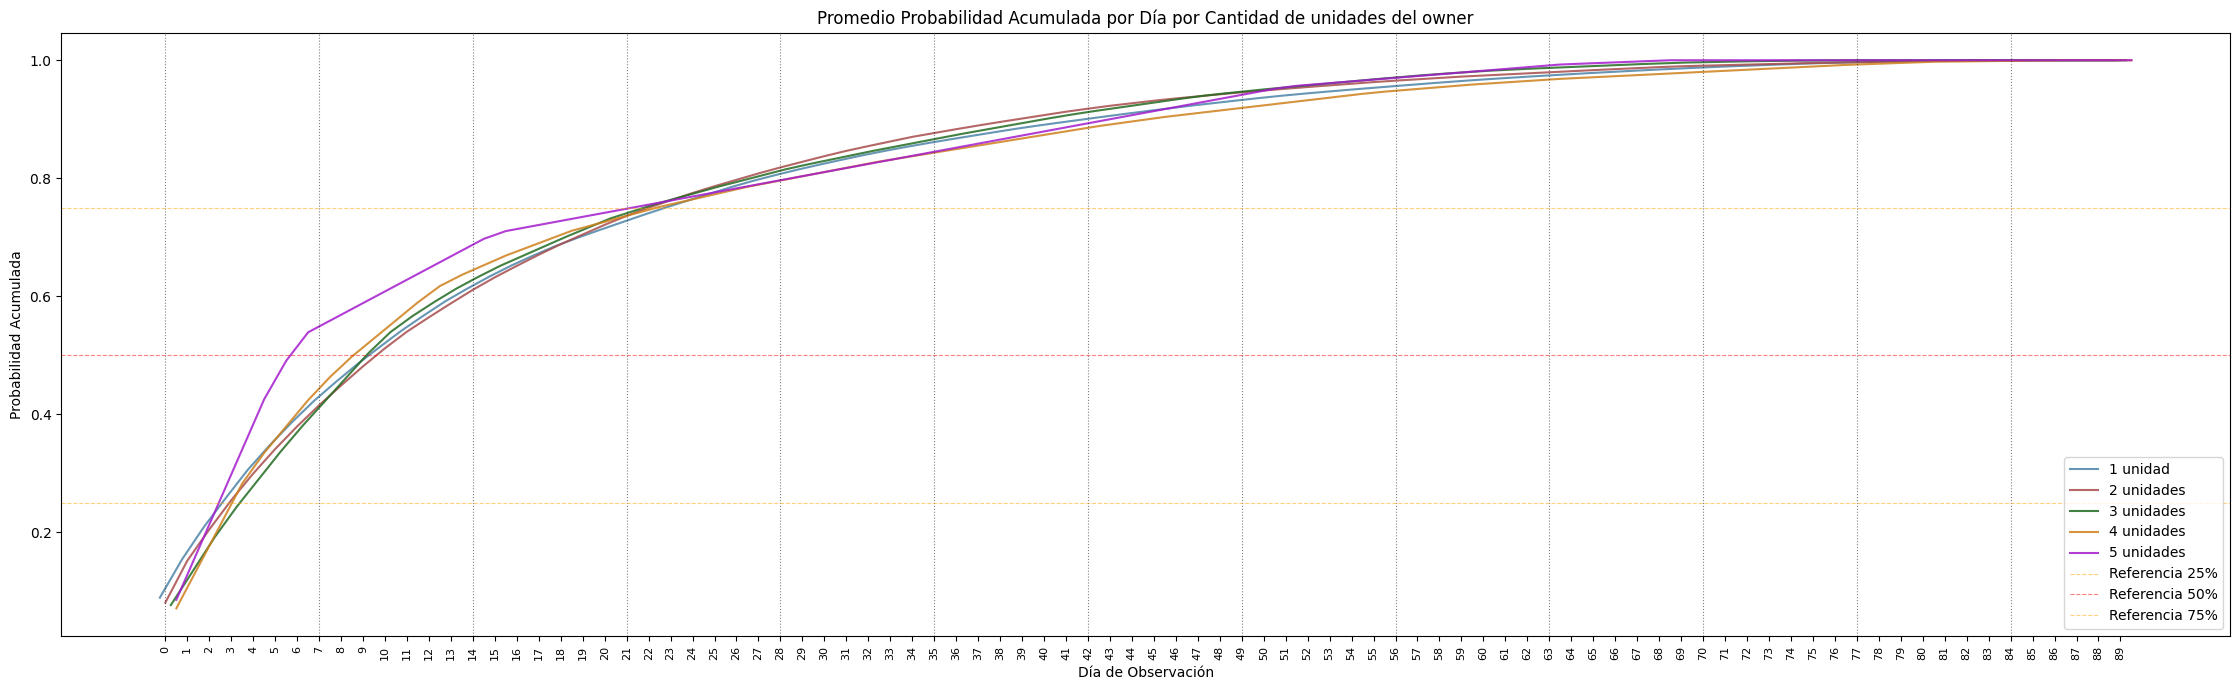

In [18]:
# 2. Setup the X positions and width

x = np.arange(max(average_per_day.index.max(), 30))  # Show at least 30 days on x-axis
width = 0.25

# Wider figure for more horizontal spacing between days
fig, ax1 = plt.subplots(figsize=(max(16, len(x) * 0.25), 7))

# X axis
ax1.plot(x - 0.25, average_per_day_churn1, color='#4C84A8', alpha=0.85, label='1 unidad')
ax1.plot(x, average_per_day_churn2, color='#A84C4C', alpha=0.85, label='2 unidades')
ax1.plot(x + 0.25, average_per_day_churn3, color="#226B22", alpha=0.85, label='3 unidades')
ax1.plot(x + 0.5, average_per_day_churn4, color="#CE801B", alpha=0.85, label='4 unidades')
ax1.plot(x + 0.5, average_per_day_churn5, color="#A41BCE", alpha=0.85, label='5 unidades')

ax1.set_xlabel('Día de Observación')
ax1.set_ylabel('Probabilidad Acumulada')

# 5. X-ticks: show every day, rotated 90° to avoid overlap
ax1.set_xticks(x)
ax1.set_xticklabels(x, rotation=90, fontsize=8)
ax1.tick_params(axis='x', which='major', pad=4)

# 6. Combined legend
h1, l1 = ax1.get_legend_handles_labels()
ax1.legend(h1, l1, title='Estado', loc='upper left')

# 7. Lines every 7 days for better readability
for day in range(0, len(x), 7):
    ax1.axvline(day, color='black', linestyle=':', linewidth=0.8, alpha=0.5) 

ax1.axhline(y=0.25, color='orange', linestyle='--', linewidth=0.8, alpha=0.5, label='Referencia 25%')
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Referencia 50%')
ax1.axhline(y=0.75, color='orange', linestyle='--', linewidth=0.8, alpha=0.5, label='Referencia 75%')

plt.legend()
plt.title('Promedio Probabilidad Acumulada por Día por Cantidad de unidades del owner')
plt.tight_layout()
plt.show()

In [ ]:
# State assignment based on days_remaining and churn status
dataframe_expanded_full['state'] = np.where(
    (dataframe_expanded_full['days_remaining'] > 0),
    'Sigue', 
    np.where(
        (dataframe_expanded_full['churn'] == 1), # Fixed parentheses here
        'Churned',
        'Arrendado'
    )
)
# Mean of properties by state and by day
state_counts = (dataframe_expanded_full.groupby(['state'])['property_id'].count()/90)
state_counts

In [ ]:

# 1. Prepare the data
counts = (
    dataframe_expanded_full
    .groupby(['duration', 'state'])['property_id']
    .count()
    .unstack(fill_value=0)
    .sort_index()
)

for col in ['Churned','Arrendado']:
    if col not in counts.columns:
        counts[col] = 0

# 2. Setup the X positions and width
x = np.arange(len(counts))
width = 0.25

# Wider figure for more horizontal spacing between days
fig, ax1 = plt.subplots(figsize=(max(16, len(counts) * 0.25), 7))

# 3. Left axis: Churned/Arrendado + Sigue
ax1.bar(x - 0.25, counts['Churned'], width, color='#4C84A8', alpha=0.85, label='Churned')
ax1.bar(x, counts['Arrendado'],   width, color='#E45756', alpha=0.85, label='Arrendado')
ax1.set_xlabel('Día de Observación')
ax1.set_ylabel('Unidade')

# 5. X-ticks: show every day, rotated 90° to avoid overlap
ax1.set_xticks(x)
ax1.set_xticklabels(counts.index, rotation=90, fontsize=8)
ax1.tick_params(axis='x', which='major', pad=4)

# 6. Combined legend
h1, l1 = ax1.get_legend_handles_labels()
ax1.legend(h1, l1, title='Estado', loc='upper left')

# 7. Lines every 7 days for better readability
for day in range(0, len(counts), 7):
    ax1.axvline(day, color='black', linestyle=':', linewidth=0.8, alpha=0.5) 

plt.title('Distribución Días de Observación por Estado')
plt.tight_layout()
plt.show()


In [ ]:
# 1. Prepare the data
counts = (
    dataframe_expanded_full
    .groupby(['day_of_observation', 'state'])['property_id']
    .count()
    .unstack(fill_value=0)
    .sort_index()
)

for col in ['Sigue']:
    if col not in counts.columns:
        counts[col] = 0

# 2. Setup the X positions and width
x = np.arange(len(counts))
width = 0.25

# Wider figure for more horizontal spacing between days
fig, ax1 = plt.subplots(figsize=(max(16, len(counts) * 0.25), 7))

# 3. Left axis: Sigue
ax1.bar(x, counts['Sigue'], width, color="#2E8B57", alpha=0.85, label='Sigue')
ax1.set_ylim(0, counts['Sigue'].max() * 1.1)
ax1.set_xlabel('Día de Observación')
ax1.set_ylabel('Unidades (Sigue)')

# 5. X-ticks
ax1.set_xticks(x)
ax1.set_xticklabels(counts.index, rotation=90, fontsize=8)
ax1.tick_params(axis='x', which='major', pad=4)

# 6. Legend
h1, l1 = ax1.get_legend_handles_labels()
ax1.legend(h1, l1, title='Estado', loc='upper left')

# 7. Lines every 7 days for better readability
for day in range(0, len(counts), 7):
    ax1.axvline(day, color='black', linestyle=':', linewidth=0.8, alpha=0.5) 

plt.title('Distribución Días de Observación por Estado')
plt.tight_layout()
plt.show()

In [ ]:
# State assignment based on days_remaining and churn status
dataframe_expanded_full['state2'] = np.where(
    (dataframe_expanded_full['days_remaining'] > 0),
    'Sigue',
    'Churned/Arrendado'
    )

# 1. Prepare the data
counts = (
    dataframe_expanded_full
    .groupby(['day_of_observation', 'state2'])['property_id']
    .count()
    .unstack(fill_value=0)
    .sort_index()
)

for col in ['Churned/Arrendado', 'Sigue']:
    if col not in counts.columns:
        counts[col] = 0

# 2. Setup the X positions and width
x = np.arange(len(counts))
width = 0.25

# Wider figure for more horizontal spacing between days
fig, ax1 = plt.subplots(figsize=(max(16, len(counts) * 0.25), 7))
ax2 = ax1.twinx()

# 3. Left axis: Churned/Arrendado + Sigue
ax1.bar(x - 0.25, counts['Churned/Arrendado'], width, color="#CA7301", alpha=0.85, label='Churned/Arrendado')
ax2.bar(x, counts['Sigue'],   width, color="#2E8B57", alpha=0.85, label='Sigue')
ax1.set_xlabel('Día de Observación')
ax2.set_ylabel('Unidades (Sigue)')
ax1.set_ylabel('Unidades (Churned/Arrendado)')

# 5. X-ticks: show every day, rotated 90° to avoid overlap
ax1.set_xticks(x)
ax1.set_xticklabels(counts.index, rotation=90, fontsize=8)
ax1.tick_params(axis='x', which='major', pad=4)

# 6. Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, title='Estado', loc='upper right')

# 7. Lines every 7 days for better readability
for day in range(0, len(counts), 7):
    ax1.axvline(day, color='black', linestyle=':', linewidth=0.8, alpha=0.5) 

plt.title('Distribución Días de Observación por Estado')
plt.tight_layout()
plt.show()